# Week 08: GPT-2 Implementation

## Text as Data

Professor: Elliott Ash, NYU

TA: Eduardo Zago, NYU

Last class we covered enhanced self-attention (Q/K/V matrices), causal masking, and multi-head attention. Today we finally put it all together into a working GPT-2 model.

Objectives:

1) Layer Normalization
2) GELU Activation & Feed Forward Network
3) Shortcut (Residual) Connections
4) Transformer Block
5) Full GPT-2 Architecture
6) Text Generation

Code adapted from Raschka Ch: 4.1–4.7

In [1]:
# set random seed
!pip install torch --upgrade
!pip install tiktoken

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tiktoken

torch.manual_seed(123)

---
## 1. The GPT Architecture: Big Picture

Last week we implemented multi-head causal attention. Today we build the full GPT-2 architecture around it. GPT-2 consists of:

- **Token + Positional Embeddings**
- **N × Transformer Blocks** (each with multi-head attention + feed forward network)
- **Final Layer Normalization**
- **Linear Output Head** (projects to vocabulary size)

We start with a configuration dictionary — the exact settings of GPT-2 Small (124M parameters):

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # BPE vocabulary size (same as tiktoken gpt2)
    "context_length": 1024,  # Maximum sequence length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of transformer blocks
    "drop_rate": 0.1,        # Dropout probability
    "qkv_bias": False        # No bias in Q/K/V projections (modern convention)
}

We will build up the model component by component, replacing placeholders with real implementations as we go. Let's start with a placeholder ("Dummy") model to see the overall shape:

In [3]:
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    def forward(self, x):
        return x   # Pass-through for now

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    def forward(self, x):
        return x   # Pass-through for now

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

# Tokenize two example Supreme Court sentences
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "The court affirmed the lower"
txt2 = "The defendant argued that the"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)

torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Input shape: ", batch.shape)
print("Output shape:", logits.shape)  # (batch=2, tokens=5, vocab=50257)

Input shape:  torch.Size([2, 5])
Output shape: torch.Size([2, 5, 50257])


The output shape `[2, 5, 50257]` tells us: for each of the 2 input sequences, for each of the 5 tokens, we get a score over the 50,257 vocabulary entries. The token with the highest score is the model's prediction for "what comes next".

Now let's replace the dummy components with real ones.

---
## 2. Layer Normalization

Deep networks suffer from **vanishing/exploding gradients**: as we stack many layers, the signal either shrinks to zero or blows up. Layer normalization fixes this by rescaling each layer's output to have **mean = 0** and **variance = 1** before passing it to the next layer.

$$\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}$$

Unlike **batch normalization** (which normalizes across the batch dimension), layer normalization normalizes across the *feature* dimension for each sample independently. This matters for LLMs because batch sizes can be small or even 1 during inference.

Let's see what normalization does in practice:

In [4]:
torch.manual_seed(123)
torch.set_printoptions(sci_mode=False)
batch_example = torch.randn(2, 5)  # 2 samples, 5 features each
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print("Layer output:\n", out)

mean = out.mean(dim=-1, keepdim=True)   # Mean per sample (across features)
var  = out.var(dim=-1, keepdim=True)    # Variance per sample
print("\nMean (before normalization):\n", mean)
print("Variance (before normalization):\n", var)

Layer output:
 tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

Mean (before normalization):
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance (before normalization):
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [5]:
# Manually apply normalization
out_norm = (out - mean) / torch.sqrt(var)
print("Normalized output:\n", out_norm)
print("\nMean after normalization:\n",     out_norm.mean(dim=-1, keepdim=True))
print("Variance after normalization:\n", out_norm.var(dim=-1, keepdim=True))

Normalized output:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)

Mean after normalization:
 tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance after normalization:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Now let's package this into a learnable PyTorch module. We add two trainable parameters — `scale` (γ) and `shift` (β) — that let the network *undo* the normalization if needed:

$$y = \gamma \hat{x} + \beta$$

In [6]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))   # γ — initialized to 1
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # β — initialized to 0

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

# Test it
ln = LayerNorm(emb_dim=6)
out_ln = ln(out)
print("Mean after LayerNorm:\n",     out_ln.mean(dim=-1, keepdim=True))
print("Variance after LayerNorm:\n", out_ln.var(dim=-1, unbiased=False, keepdim=True))

Mean after LayerNorm:
 tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Variance after LayerNorm:
 tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)


---
## 3. GELU Activation & Feed Forward Network

GPT-2 uses the **GELU** (Gaussian Error Linear Unit) activation instead of the simpler ReLU. The key difference: GELU is smooth and allows small, non-zero outputs for negative inputs, which improves gradient flow during training.

$$\text{GELU}(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}}\left(x + 0.044715 x^3\right)\right]\right)$$

This is an approximation so it should not make a lot of sense. The actual function is:

$$\text{GELU}(x) = x \Phi (x)$$

where $\Phi()$ is the cumulative distribution function of the standard Gaussian distribution.

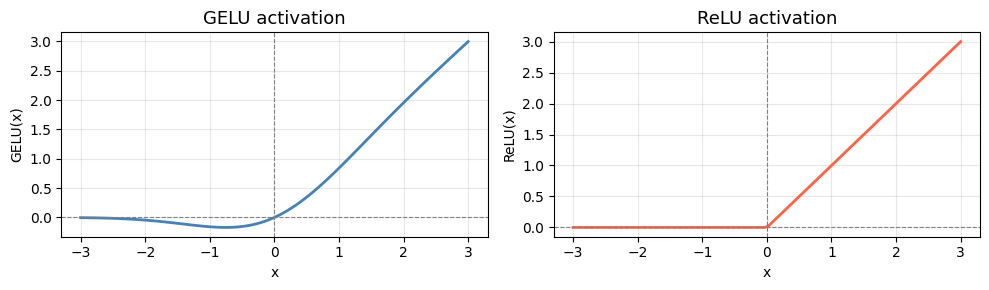

Notice: GELU is smooth near 0, ReLU has a hard corner.
GELU allows small negative outputs — keeps gradient information alive.


In [7]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

# Compare GELU vs ReLU visually
gelu = GELU()
relu = nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu = gelu(x)
y_relu = relu(x)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, y, label, color in zip(axes, [y_gelu, y_relu], ["GELU", "ReLU"], ["steelblue", "tomato"]):
    ax.plot(x.numpy(), y.numpy(), color=color, linewidth=2)
    ax.set_title(f"{label} activation", fontsize=13)
    ax.set_xlabel("x")
    ax.set_ylabel(f"{label}(x)")
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Notice: GELU is smooth near 0, ReLU has a hard corner.")
print("GELU allows small negative outputs — keeps gradient information alive.")

### Feed Forward Network

Each transformer block contains a small two-layer network applied **independently to each token position**. It expands the embedding from 768 → 3072 (×4), applies GELU, then contracts back to 768:

In [8]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),  # Expand: cfg["emb_dim"] = 768 → 3072
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),  # Contract: 3072 → 768
        )

    def forward(self, x):
        return self.layers(x)

# Test: input and output shape must be identical
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 5, 768)   # batch=2, tokens=5, emb=768
out = ffn(x)
print("FeedForward input  shape:", x.shape)
print("FeedForward output shape:", out.shape)  # Same shape — token positions are independent

FeedForward input  shape: torch.Size([2, 5, 768])
FeedForward output shape: torch.Size([2, 5, 768])


---
## 4. Shortcut (Residual) Connections

The deeper a network gets, the harder it is to train: gradients shrink as they travel backward through many layers (vanishing gradient problem). **Shortcut connections** (also called skip or residual connections) solve this by creating a direct path for gradients to bypass layers:

$$x_{\text{out}} = x_{\text{in}} + \text{layer}(x_{\text{in}})$$

This means gradients always have a "highway" back to early layers, regardless of how deep the network is. Let's see this effect concretely:

In [9]:
class ExampleDeepNN(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[i], layer_sizes[i+1]), GELU())
            for i in range(len(layer_sizes) - 1)
        ])

    def forward(self, x):
        for layer in self.layers:
            out = layer(x)
            if self.use_shortcut and x.shape == out.shape:
               # Add the layer's input directly to its output.
                #
                # Why the shape check?  Addition requires identical dimensions.
                # A layer that changes size (e.g. 4→1) can't use a shortcut —
                # there's no way to add a length-4 vector to a length-1 vector.
                #
                # What does this buy us?
                #   • During backprop, gradients can flow through the '+' path
                #     unchanged (derivative of x+out w.r.t. x is 1).
                #   • Early layers receive much stronger gradient signals →
                #     the network trains faster and more reliably.
                x = x + out   # Residual connection
            else:
                x = out
        return x

def print_gradients(model, x):
    target = torch.zeros(x.shape[0], 1)
    loss = nn.MSELoss()(model(x), target)
    loss.backward()
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"  {name}: gradient mean = {param.grad.abs().mean().item():.6f}")

layer_sizes = [3, 3, 3, 3, 3, 1]
x = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
print("WITHOUT shortcut connections:")
print_gradients(ExampleDeepNN(layer_sizes, use_shortcut=False), x)

torch.manual_seed(123)
print("\nWITH shortcut connections:")
print_gradients(ExampleDeepNN(layer_sizes, use_shortcut=True), x)

WITHOUT shortcut connections:
  layers.0.0.weight: gradient mean = 0.000202
  layers.1.0.weight: gradient mean = 0.000120
  layers.2.0.weight: gradient mean = 0.000715
  layers.3.0.weight: gradient mean = 0.001399
  layers.4.0.weight: gradient mean = 0.005050

WITH shortcut connections:
  layers.0.0.weight: gradient mean = 0.221698
  layers.1.0.weight: gradient mean = 0.206941
  layers.2.0.weight: gradient mean = 0.328970
  layers.3.0.weight: gradient mean = 0.266573
  layers.4.0.weight: gradient mean = 1.325854


Notice: without shortcuts, gradients shrink dramatically from the last layer to the first (layers.0 vs layers.4). With shortcuts, the gradient magnitudes stay in a similar range across all layers — this is what allows GPT-2's 12 (or 48!) stacked transformer blocks to train effectively.

---
## 5. Multi-Head Attention (from last week)

We need the `MultiHeadAttention` class we built last week. Here it is in its final form, using a single combined Q/K/V projection for efficiency:

In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # Split into heads: (b, num_tokens, num_heads, head_dim) → (b, num_heads, num_tokens, head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2).contiguous()
        context_vec = context_vec.view(b, num_tokens, self.d_out)
        return self.out_proj(context_vec)

# Quick test
torch.manual_seed(123)
mha = MultiHeadAttention(d_in=768, d_out=768, context_length=1024,
                          dropout=0.0, num_heads=12)
x_test = torch.rand(2, 5, 768)
print("MHA output shape:", mha(x_test).shape)  # Should be (2, 5, 768)

MHA output shape: torch.Size([2, 5, 768])


---
## 6. The Transformer Block

Now we can assemble our core building block. Each transformer block applies:

1. **LayerNorm** → **Multi-Head Attention** → **Dropout** → **+ Residual**
2. **LayerNorm** → **FeedForward** → **Dropout** → **+ Residual**

Note: GPT-2 uses **Pre-LayerNorm** (normalize *before* the sub-layer), unlike the original 2017 transformer which normalized *after*. Pre-LayerNorm leads to more stable training.

In [11]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # ── Attention sub-layer with residual connection ──
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut    # Add residual

        # ── Feed forward sub-layer with residual connection ──
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut    # Add residual
        return x

# Test
torch.manual_seed(123)
x = torch.rand(2, 5, 768)
block = TransformerBlock(GPT_CONFIG_124M)
out = block(x)
print("TransformerBlock input  shape:", x.shape)
print("TransformerBlock output shape:", out.shape)
print("Shape is preserved! Each token is re-encoded but dimensions stay the same.")

TransformerBlock input  shape: torch.Size([2, 5, 768])
TransformerBlock output shape: torch.Size([2, 5, 768])
Shape is preserved! Each token is re-encoded but dimensions stay the same.


---
## 7. The Full GPT-2 Model

We now have everything we need. The full model stacks N=12 transformer blocks between the embedding layers and the output head:

In [12]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack N transformer blocks
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        # Output head: maps each token's 768-dim vector to vocab scores
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

# Use our SC opinion sentences from before
tokenizer = tiktoken.get_encoding("gpt2")
batch = torch.stack([
    torch.tensor(tokenizer.encode("The court affirmed the lower")),
    torch.tensor(tokenizer.encode("The defendant argued that the"))
], dim=0)

out = model(batch)
print("Input shape: ", batch.shape)
print("Output shape:", out.shape)   # (2, 5, 50257)

Input shape:  torch.Size([2, 5])
Output shape: torch.Size([2, 5, 50257])


### Parameter Count

How many parameters does our model have?

In [13]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Why 163M and not 124M?
# Because we have separate embedding and output layers.
# The original GPT-2 used 'weight tying' — the output layer reuses
# the token embedding weights. Let's check their shapes:
print(f"\nToken embedding shape: {model.tok_emb.weight.shape}")
print(f"Output head shape:     {model.out_head.weight.shape}")

# Subtract the output head to match the original 124M count
params_no_out = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"\nParameters with weight tying (as in original GPT-2): {params_no_out:,}")

# Memory footprint (float32 = 4 bytes per parameter)
size_mb = total_params * 4 / (1024 ** 2)
print(f"Model size (float32): {size_mb:.1f} MB")

Total parameters: 163,009,536

Token embedding shape: torch.Size([50257, 768])
Output head shape:     torch.Size([50257, 768])

Parameters with weight tying (as in original GPT-2): 124,412,160
Model size (float32): 621.8 MB


---
## 8. Text Generation

Our model produces logits of shape `[batch, tokens, vocab_size]`. To generate text, we:

1. Take the logits for the **last token position** (this is the prediction for "what comes next")
2. Convert logits → probabilities with softmax
3. Pick the token with the **highest probability** (greedy decoding)
4. Append it to the input and repeat

This is called **autoregressive** generation: the model generates one token at a time, feeding each new token back as context.

In [14]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    """
    Greedy autoregressive text generation.
    idx: (batch, n_tokens) tensor of current token IDs
    """
    for _ in range(max_new_tokens):
        # Crop to the model's context window if needed
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        # Only the last position matters — that's the next-token prediction
        logits = logits[:, -1, :]                         # (batch, vocab_size)
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append the new token to the sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

# Try it on a SC opinion fragment
start_context = "The Supreme Court held that"
encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # Add batch dimension

model.eval()  # Disable dropout for inference
out_ids = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

decoded = tokenizer.decode(out_ids.squeeze(0).tolist())
print("Generated text:")
print(decoded)

Generated text:
The Supreme Court held thatsteam 1933hash1969 segments contemplating billed793 realiseSIGN


The output is gibberish — that's expected! We initialized the model with **random weights**. The architecture is correct, but it hasn't seen any data yet.

For now, note that the generation mechanism itself is already working: the model is producing valid token IDs and decoding them to text. It just doesn't know anything useful yet.

# Training on unlabelled data

Objectives:

1) Computing cross-entropy loss
2) Training & validation data loaders
3) The training loop
4) Decoding strategies (temperature + top-k)
5) Saving & loading model weights

Code adapted from Raschka Ch: 5.1–5.4

In [15]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    return torch.tensor(encoded).unsqueeze(0)   # adds batch dimension

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)                 # removes batch dimension
    return tokenizer.decode(flat.tolist())

# Quick test with a Supreme Court phrase
test = "The court affirmed"
ids  = text_to_token_ids(test, tokenizer)
print("Token IDs:", ids)
print("Back to text:", token_ids_to_text(ids, tokenizer))

Token IDs: tensor([[  464,  2184, 31036]])
Back to text: The court affirmed


## 2. Computing the Loss

### What are we measuring?

At every position in a sequence the model outputs a probability score over all 50,257 vocabulary tokens. Training works by maximizing the probability assigned to the **correct next token**. Equivalently, we minimize the **cross-entropy loss**:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log P(\text{target}_i)$$

The lower the loss, the closer the model's predictions are to the ground truth. A randomly initialized model on a 50,257-word vocabulary gives a loss of roughly $\log(50257) \approx 10.8$.

Let's see the steps manually first:

In [16]:
# Initialize a fresh (untrained) model with a shorter context for speed
GPT_CONFIG_TRAIN = {
    "vocab_size": 50257,
    "context_length": 256,   # Shorter than 1024 for fast training on CPU
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_TRAIN)
model.eval()

# Two short example inputs and their targets (targets = inputs shifted by 1)
inputs  = torch.tensor([[16833, 3626, 6100],   # "every effort moves"
                        [40,    1107,  588]])   # "I really like"
targets = torch.tensor([[3626,  6100,  345],   # "effort moves you"
                        [1107,   588, 11311]])  # "really like chocolate"

with torch.no_grad():
    logits = model(inputs)                          # (2, 3, 50257)
probas = torch.softmax(logits, dim=-1)

# Step 3: grab the probability assigned to each correct target token
target_probas_1 = probas[0, [0,1,2], targets[0]]
target_probas_2 = probas[1, [0,1,2], targets[1]]
print("Prob of correct tokens — text 1:", target_probas_1)
print("Prob of correct tokens — text 2:", target_probas_2)

Prob of correct tokens — text 1: tensor([0.0001, 0.0000, 0.0000])
Prob of correct tokens — text 2: tensor([0.0000, 0.0001, 0.0000])


In [17]:
# Steps 4-6: log → average → negate  (= cross-entropy)
log_probas     = torch.log(torch.cat([target_probas_1, target_probas_2]))
avg_log_probas = log_probas.mean()
neg_avg_log    = -avg_log_probas
print(f"Manual cross-entropy loss: {neg_avg_log:.4f}")

# PyTorch does all 6 steps in one call:
loss = torch.nn.functional.cross_entropy(
    logits.flatten(0, 1),   # (6, 50257)
    targets.flatten()       # (6,)
)
print(f"PyTorch cross-entropy loss: {loss:.4f}")
print(f"Perplexity: {torch.exp(loss):.1f}  ← model is uncertain among ~{torch.exp(loss):.0f} tokens")

Manual cross-entropy loss: 10.7940
PyTorch cross-entropy loss: 10.7940
Perplexity: 48725.8  ← model is uncertain among ~48726 tokens


**Perplexity** = $e^{\text{loss}}$ — a more intuitive number. After random init it equals ~48,000 (the model has no idea which of 50,257 tokens comes next). After training on a large corpus it drops to ~30–50 for fluent text.

---
## 3. Training & Validation Data Loaders

We'll train on a small public-domain text (Edith Wharton's *The Verdict*) so the whole loop runs in minutes on a laptop. The same code scales to any corpus.

We split 90% train / 10% validation. Each batch is a sliding window of 256 tokens; input and target are offset by one position.

In [18]:
# Download "The Verdict" short story
import urllib.request
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"
urllib.request.urlretrieve(url, "the-verdict.txt")

with open("the-verdict.txt", "r", encoding="utf-8") as f:
    text_data = f.read()

total_tokens = len(tokenizer.encode(text_data))
print(f"Characters: {len(text_data):,}  |  Tokens: {total_tokens:,}")

Characters: 20,479  |  Tokens: 5,145


In [19]:
# Data loader from 2 sessions ago:

from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt) # Tokenizes the entire text

        for i in range(0, len(token_ids) - max_length, stride):  # Uses a sliding window to chunk the articles into overlapping sequences of max_length
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self): # Returns the total number of rows in the dataset
        return len(self.input_ids)

    def __getitem__(self, idx):  # Returns a single row from the dataset
        return self.input_ids[idx], self.target_ids[idx]

# Now A data loader to generate batches with input-with pairs
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2") # Initializes the tokenizer
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride) # Creates dataset
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last, # drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes during training. (See Rashkca A6)
        num_workers=num_workers  # The number of CPU processes to use for preprocessing
    )

    return dataloader

In [20]:
# 90 / 10 split
split_idx  = int(0.90 * len(text_data))
ctx        = GPT_CONFIG_TRAIN["context_length"]

torch.manual_seed(123)
train_loader = create_dataloader_v1(text_data[:split_idx], batch_size=2,
                                    max_length=ctx, stride=ctx,
                                    shuffle=True, drop_last=True)
val_loader   = create_dataloader_v1(text_data[split_idx:], batch_size=2,
                                    max_length=ctx, stride=ctx,
                                    shuffle=False, drop_last=False)

print("Train batches:", len(train_loader))
print("Val   batches:", len(val_loader))
for x, y in train_loader: print("Batch shape:", x.shape); break

Train batches: 9
Val   batches: 1
Batch shape: torch.Size([2, 256])


## 4. The Training Loop

The loop follows the standard PyTorch recipe:

1. Forward pass → compute loss
2. `loss.backward()` → compute gradients
3. `optimizer.step()` → update weights
4. Periodically evaluate on validation set & print a sample

We use the **AdamW** optimizer — a variant of Adam that adds proper weight decay (L2 regularization), which helps prevent overfitting.

In [23]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)         #1
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)     #1
    else:
        num_batches = min(num_batches, len(data_loader))   #2
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()    #3
        else:
            break
    return total_loss / num_batches    #4

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, eval_iter)
        val_loss   = calc_loss_loader(val_loader,   model, device, eval_iter)
    model.train()
    return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    ctx_size = model.pos_emb.weight.shape[0]
    encoded  = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(model, encoded,
                                         max_new_tokens=50,
                                         context_size=ctx_size)
    print(token_ids_to_text(token_ids, tokenizer).replace("\n", " "))
    model.train()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)   #1
with torch.no_grad():                                        #2
    train_loss = calc_loss_loader(train_loader, model, device)    #3
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987583266364204
Validation loss: 10.98110580444336


In [22]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []    #1
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):    #2
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()   #3
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()                     #4
            optimizer.step()                    #5
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:    #6
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(                      #7
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen

In [24]:
# ── Train for 10 epochs (~ 3–5 min on CPU)
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_TRAIN).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=0.1)

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=10, eval_freq=5, eval_iter=5,
    start_context="The Supreme Court held",
    tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.818, Val loss 9.930
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.336
The Supreme Court held,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.623, Val loss 7.053
Ep 2 (Step 000015): Train loss 6.047, Val loss 6.605
The Supreme Court held,,,, and,,,,,,, and,.                                   
Ep 3 (Step 000020): Train loss 5.532, Val loss 6.507
Ep 3 (Step 000025): Train loss 5.399, Val loss 6.389
The Supreme Court held.                                                 
Ep 4 (Step 000030): Train loss 4.895, Val loss 6.280
Ep 4 (Step 000035): Train loss 4.648, Val loss 6.304
The Supreme Court held.  "I the picture.  "I had the picture.            "I"I the picture"I had the the honour of the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 4.023, Val loss 6.165
The Supreme Court held I  "Oh, and he had been the fact a little of the.                   "Oh, and he had been the man of the   
Ep 6 (Step 0

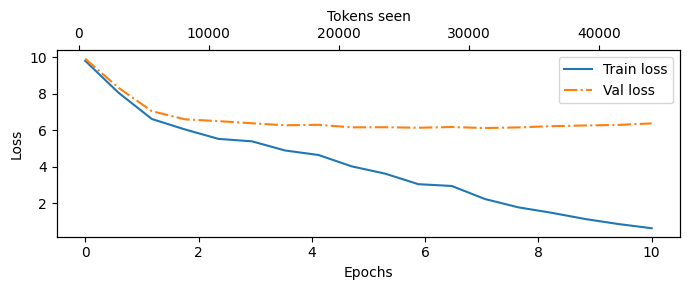

In [26]:
# ── Plot training vs validation loss
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(7, 3))
    ax1.plot(epochs_seen, train_losses, label="Train loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Val loss")
    ax1.set_xlabel("Epochs"); ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    plt.tight_layout(); plt.show()

epochs_tensor = torch.linspace(0, 10, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

**What to look for in the plot:**

- Both losses should drop sharply in the first epoch — the model is learning.
- If the **training loss keeps falling but validation loss stagnates or rises**, the model is **overfitting** (memorizing the training text). This is expected here because our dataset is tiny (~5,000 tokens). On a large corpus (millions of tokens), overfitting is far less of a concern.

Next class we will see:

1) Decoding strategies (temperature + top-k)
2) Saving & loading model weights
3) Finetuning for classification and to follow instructions
